# $h$-Means: A Practical $\mathbb{R}^n$ Optimisation Example

So far we have tested our heuristics on **synthetic benchmarks** — De Jong 1 (a smooth bowl) and Rastrigin (a regular grid of traps). These are useful for understanding algorithm behaviour, but they are not real problems anyone needs to solve.

**$h$-means** is a first example of a *practical* application: heuristic cluster analysis inspired by [$k$-means](https://en.wikipedia.org/wiki/K-means_clustering). The idea is to treat cluster centroid positions as a continuous vector and let FSA (or any $\mathbb{R}^n$ heuristic) search for the best placement — without any modification to the heuristic itself.

**Optimisation problem:** given data points $\mathbf{X} \in \mathbb{R}^{n \times d}$ and a target cluster count $h$, find centroid positions $C \in \mathbb{R}^{h \times d}$ minimising the sum of squared distances to the nearest centroid:

$$f(C) = \sum_{i=1}^{n} \min_{j=1,\ldots,h} \| \mathbf{x}_i - c_j \|^2$$

The heuristic sees a flat $\mathbb{R}^{h \cdot d}$ vector; `encode_solution`/`decode_solution` handle reshaping to and from the centroid matrix.

This notebook covers:
1. The objective function — data generation, domain, evaluation
2. Penalisation — why a penalty term is needed and how to calibrate $\lambda$
3. Optimisation — running FSA and comparing to the ground truth

In [1]:
import sys
import os
pwd = %pwd
sys.path.append(os.path.join(pwd, '..', 'src'))

%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from objfun_hmeans import HMeans
from heur_fsa import FastSimulatedAnnealing
from heur_aux import CauchyMutation, MirrorCorrection

## 1. The Objective Function

`HMeans` generates a synthetic clustering dataset: `n_clu` true cluster centres are sampled uniformly from $[0,1]^d$, then `n_pts` data points are drawn around each centre from $\mathcal{N}(c,\, \sigma^2 I)$.

The heuristic solution vector is the **flattened** centroid matrix of shape $(h \cdot d,)$. The domain bounds `a` and `b` are derived from the data extent and repeated for each centroid — the heuristic treats all $h \cdot d$ coordinates as independent continuous variables.

Unlike De Jong 1 or Rastrigin, $f^*$ is not known analytically; it is approximated by evaluating the objective at the true generating centroids and adding a small tolerance $\varepsilon$.

In [3]:
of = HMeans(dim=2, n_clu=3, n_pts=15)

print(f'Solution dimension : {len(of.a)}  ({of.n_clu} centroids × {of.dim} dims)')
print(f'Domain lower bound : {of.a}')
print(f'Domain upper bound : {of.b}')
print(f'f*  (approx.)      : {of.fstar:.6f}')
print()
print('True cluster centres (the target we are trying to recover):')
print(of.C)

Solution dimension : 6  (3 centroids × 2 dims)
Domain lower bound : [0.46018284 0.03965729 0.46018284 0.03965729 0.46018284 0.03965729]
Domain upper bound : [1.00518748 0.28479702 1.00518748 0.28479702 1.00518748 0.28479702]
f*  (approx.)      : 0.266014

True cluster centres (the target we are trying to recover):
[[0.95600171 0.20768181]
 [0.82844489 0.14928212]
 [0.51280462 0.1359196 ]]


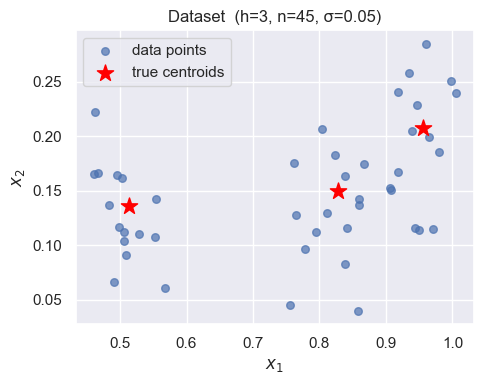

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(of.X[:, 0], of.X[:, 1], s=30, alpha=0.7, label='data points')
ax.scatter(of.C[:, 0], of.C[:, 1], s=150, marker='*', color='red', zorder=5, label='true centroids')
ax.set_title(f'Dataset  (h={of.n_clu}, n={len(of.X)}, σ=0.05)')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.legend()
plt.tight_layout()

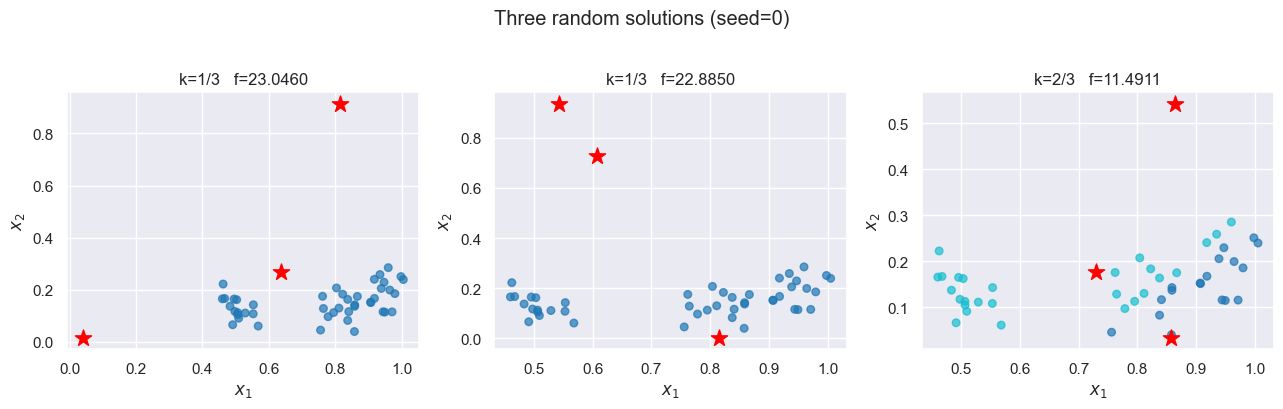

In [5]:
def visualize_solution(x, of, ax=None, title=None):
    """Plot data points coloured by cluster assignment, with centroid markers."""
    labels = of.get_cluster_labels(x)
    C = of.decode_solution(x)
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(of.X[:, 0], of.X[:, 1], c=labels, cmap='tab10', s=30, alpha=0.7)
    ax.scatter(C[:, 0], C[:, 1], s=150, marker='*', color='red', zorder=5)
    n_active = len(np.unique(labels))
    ax.set_title(title or f'k={n_active}/{of.n_clu}   f={of.evaluate(x):.4f}')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    return ax

# Three random solutions drawn with a fixed seed — students will see the same output
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax in axes:
    visualize_solution(of.generate_point(rng), of, ax=ax)
plt.suptitle('Three random solutions (seed=0)', y=1.02)
plt.tight_layout()

## 2. Penalisation

The SSQ objective has a structural ambiguity: nothing prevents the heuristic from placing two centroids at the same location, effectively solving a $(h-1)$-cluster problem instead of an $h$-cluster one. A **penalty term** discourages this:

$$f_\lambda(C) = f(C) + \lambda \cdot (h - k_{\text{active}})$$

where $k_{\text{active}}$ is the number of centroids that are the nearest centroid for at least one data point.

### How to choose $\lambda$?

The penalty should be large enough that collapsing any cluster is always worse than keeping it active. We can derive a data-driven lower bound:

- Let $\text{SSQ}_1$ be the SSQ when **all** points are assigned to the global centroid — the worst-case baseline for $k=1$.
- Let $\text{SSQ}^*$ be the SSQ at the true cluster centres.
- The total SSQ improvement from using $h$ clusters instead of 1 is $\Delta = \text{SSQ}_1 - \text{SSQ}^*$, and by a convexity argument each cluster contributes on average $\Delta/h$ of that improvement.

For collapsing one cluster to always be costly:

$$\boxed{\lambda_{\min} = \frac{\text{SSQ}_1 - \text{SSQ}^*}{h}}$$

Both quantities are computable from the data **before** running any heuristic.

In [6]:
# SSQ_1: assign every point to the global centroid
global_centroid = of.X.mean(axis=0)
ssq_1 = float(np.sum(np.linalg.norm(of.X - global_centroid, axis=1) ** 2))

# SSQ*: evaluate at the true centroids.
# All h centroids are active at the true solution, so the penalty term is zero
# regardless of lambda_ — we can use the existing `of` object directly.
ssq_opt = float(of.evaluate(of.encode_solution(of.C)))

lambda_min = (ssq_1 - ssq_opt) / of.n_clu

print(f'SSQ_1  (k=1 baseline) = {ssq_1:.4f}')
print(f'SSQ*   (k=3, optimal) = {ssq_opt:.4f}')
print(f'Delta                 = {ssq_1 - ssq_opt:.4f}')
print()
print(f'lambda_min = {ssq_1 - ssq_opt:.4f} / {of.n_clu} = {lambda_min:.4f}')

SSQ_1  (k=1 baseline) = 1.7510
SSQ*   (k=3, optimal) = 0.1660
Delta                 = 1.5850

lambda_min = 1.5850 / 3 = 0.5283


## 3. Optimisation

We run FSA with the calibrated penalty. `T0`, `n0`, and `alpha` are standard FSA defaults; `r=0.05` is chosen to match the domain scale (the data occupies a region roughly $0.3$–$0.5$ units wide in each dimension). The `seed=0` argument makes the run fully reproducible — every student should see the same output.

best_y  = 0.254776  (f* = 0.266014)
neval   = 56
success = True
active clusters: 3 / 3


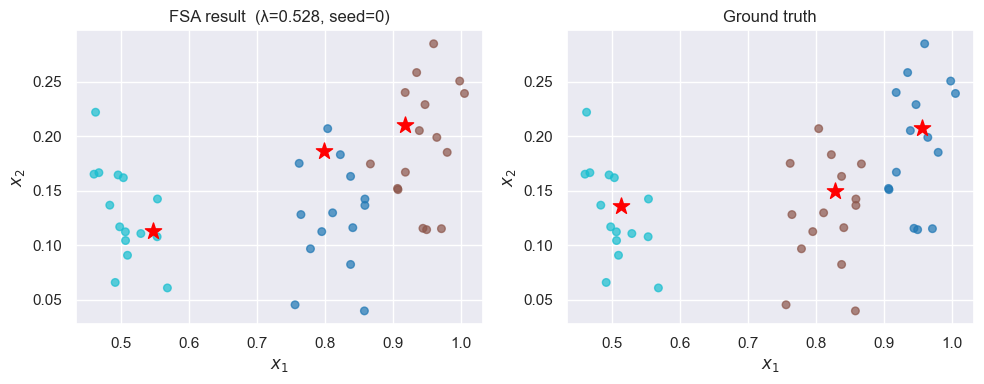

In [7]:
MAXEVAL = 2000

of_final = HMeans(dim=2, n_clu=3, n_pts=15, lambda_=lambda_min)
mut = CauchyMutation(r=0.05, correction=MirrorCorrection(of_final))
res = FastSimulatedAnnealing(of_final, maxeval=MAXEVAL, T0=5, n0=20, alpha=2,
                              mutation=mut, seed=0).search()

print(f'best_y  = {res["best_y"]:.6f}  (f* = {of_final.fstar:.6f})')
print(f'neval   = {res["neval"]}')
print(f'success = {res["success"]}')
print(f'active clusters: {len(np.unique(of_final.get_cluster_labels(res["best_x"])))} / {of_final.n_clu}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
visualize_solution(res['best_x'], of_final, ax=axes[0],
                   title=f'FSA result  (λ={lambda_min:.3f}, seed=0)')
visualize_solution(of_final.encode_solution(of_final.C), of_final,
                   ax=axes[1], title='Ground truth')
plt.tight_layout()

## Summary

### Why $h$-means?

| Property | De Jong 1 | Rastrigin | $h$-means |
|---|---|---|---|
| Domain | $\mathbb{R}^n$ | $\mathbb{R}^n$ | $\mathbb{R}^{h \cdot d}$ |
| $f^*$ known analytically | yes | yes | **no** — approximated from data |
| Practical meaning | none | none | **yes** — cluster recovery |
| Landscape | smooth bowl | regular traps | irregular, data-dependent |

The same FSA + `CauchyMutation` + `MirrorCorrection` pipeline that worked on De Jong 1 and Rastrigin solves the clustering problem without any modification — this is the key point.

### Penalisation

The penalty weight $\lambda_{\min} = (\text{SSQ}_1 - \text{SSQ}^*) / h$ provides a principled lower bound derived entirely from the data. On well-separated clusters the SSQ landscape already discourages centroid collapse, so $\lambda$ has little practical effect; on overlapping or crowded clusters it becomes essential.

### Assignments
- Run FSA without penalty (`lambda_=0`) and check whether the recovered clusters still match the ground truth. Does it matter for this dataset?
- Try `dim=3` or `n_clu=5`. How does FSA performance scale with the solution dimension $h \cdot d$?
- Compare to scikit-learn's `KMeans` on the same dataset. Which approach is more reliable? Which is faster?
  * Can you identify any optimizations? Eg. in the random number generator?